# K-Means Clustering from Scratch
Enhanced with complex data and silhouette measurement.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

## 1. Mock Data Generation

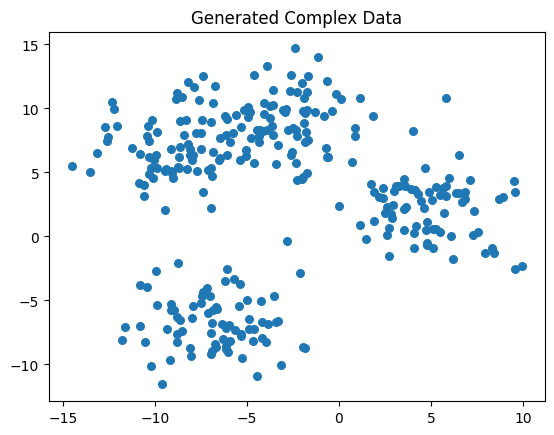

In [2]:
def get_complex_data():
    X, y = make_blobs(n_samples=300, centers=4, cluster_std=2.3, random_state=42)
    return X, y

X, y_true = get_complex_data()
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Generated Complex Data")
plt.show()

## 2. Implementation

In [3]:
import numpy as np

class KMeansCustom:
    def __init__(self, k=4, mode='plus'):
        self.k = k
        self.mode = mode

    def init_centers(self, X):
        if self.mode != 'plus':
            random_indices = np.random.choice(len(X), self.k, replace=False)
            return X[random_indices]

        centers = []
        first_index = np.random.randint(len(X))
        centers.append(X[first_index])

        for _ in range(1, self.k):
            distances = []

            for x in X:
                min_dist = float('inf')

                for c in centers:
                    dist = np.sum((x - c) ** 2)
                    if dist < min_dist:
                        min_dist = dist

                distances.append(min_dist)

            distances = np.array(distances)
            probabilities = distances / distances.sum()
            new_index = np.random.choice(len(X), p=probabilities)
            centers.append(X[new_index])

        return np.array(centers)

    def fit(self, X):
        self.centers = self.init_centers(X)

        for _ in range(20):
            labels = []

            for x in X:
                min_dist = float('inf')
                label = 0

                for i in range(self.k):
                    dist = np.linalg.norm(x - self.centers[i])
                    if dist < min_dist:
                        min_dist = dist
                        label = i

                labels.append(label)

            labels = np.array(labels)
            new_centers = []

            for i in range(self.k):
                cluster_points = []

                for j in range(len(X)):
                    if labels[j] == i:
                        cluster_points.append(X[j])

                if len(cluster_points) > 0:
                    cluster_points = np.array(cluster_points)
                    new_center = cluster_points.mean(axis=0)
                else:
                    new_center = self.centers[i]

                new_centers.append(new_center)

            new_centers = np.array(new_centers)

            if np.allclose(self.centers, new_centers):
                break

            self.centers = new_centers

        self.labels = labels
        return self

## 3. Training & Measurement

In [4]:
model = KMeansCustom(k=4, mode='plus')
model.fit(X)

score = silhouette_score(X, model.labels)
print(f"Finished fitting. Silhouette Score: {score:.4f}")

Finished fitting. Silhouette Score: 0.5548


## 4. Visualization

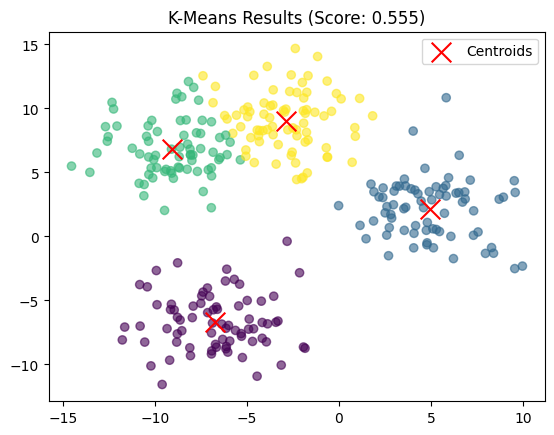

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=model.labels, cmap='viridis', alpha=0.6)
plt.scatter(model.centers[:, 0], model.centers[:, 1], color='red', marker='x', s=200, label='Centroids')
plt.title(f"K-Means Results (Score: {score:.3f})")
plt.legend()
plt.show()